# TabM：任务时间与能耗预测（v6 分离特征版）

本 Notebook 对应 `buildTaskFeatures_time_energy_v6.py`，整体结构、训练流程和绘图方式保持原来的简化版风格。

最终只训练两个回归目标：

- `task_duration_min`：去除 `speed < 0.2` 暂停时间后的任务时长，单位分钟；
- `total_energy_soc_delta_pct`：任务 SOC 能耗，单位百分点。

两套模型使用不同输入：

- **时间模型**：路线/地形 + 历史速度 + 历史耗时 + 相似任务；
- **能耗模型**：路线/地形 + 历史能耗 + 单位里程能耗 + 相似任务能耗；
- 速度不是预测目标，只是已完成历史任务中的中间量，用于增强时间预测；
- 历史耗时/历史速度不进入能耗模型；
- 两个模型分别进行缺失值处理、标准化、早停、完整训练集重训和模型保存。

流程：读取 JSON → 按时间顺序划分 → 各目标使用各自特征 → 中位数填补与标准化 → 早停确定 epoch → 完整训练集重训 → 测试集评价 → 绘图与保存结果。


## 1. 首次安装或修复依赖

首次安装时运行第一组命令。你之前出现过 `backend_agg` 导入失败；若再次出现，运行第二组“清洁重装 Matplotlib”命令，然后 **重启 Kernel**。

In [12]:
# 首次安装依赖时取消注释并运行：
# %pip install -U numpy pandas scikit-learn joblib torch tabm matplotlib matplotlib-inline

# # Matplotlib 的 backend_agg 损坏时，取消注释并运行；完成后必须重启 Kernel：
# %pip install --force-reinstall --no-deps matplotlib==3.11.1
# %pip uninstall -y matplotlib matplotlib-inline
# %pip install --no-cache-dir --force-reinstall matplotlib matplotlib-inline

## 2. 导入依赖与配置

In [13]:
import os
os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import json, math, random, re
from copy import deepcopy
from pathlib import Path
from typing import Any, Dict, Optional, Tuple

import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Image as IPythonImage
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

# ===== 必须在 import matplotlib.pyplot 之后，任何绘图之前立刻重置 =====
import matplotlib
matplotlib.rcdefaults()                 # ① 还原 rcParams
matplotlib.use("Agg")                   # ② 强制 backend（和 MPLBACKEND 对应）
import matplotlib.pyplot as plt
plt.style.use("default")                # ③ 切回 default style（清除 dark_background / seaborn 残留）

# ④ 关键：先 delete 掉可能注入的所有 Jupyter / matplotlib_inline 配置（如果有的话）
if "pylab_setup" in dir():
    pass

# ===== 从白纸开始，显式设置所有参数 =====
plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "savefig.facecolor":  "white",
    "savefig.transparent": False,

    "text.color":         "black",
    "axes.edgecolor":     "black",
    "axes.labelcolor":    "black",
    "xtick.color":        "black",
    "ytick.color":        "black",
    "xtick.labelcolor":   "black",
    "ytick.labelcolor":   "black",

    "font.family":        "sans-serif",
    "font.sans-serif":    [
        "Microsoft YaHei", "SimHei", "SimSun",
        "Microsoft YaHei UI", "DejaVu Sans",
    ],
    "axes.unicode_minus": False,

    "legend.facecolor":   "white",
    "legend.edgecolor":   "#888888",
    "legend.labelcolor":  "black",
    "legend.framealpha":  1.0,

    "grid.alpha":         0.2,
    "grid.color":         "#cccccc",
    "axes.grid":          False,

    "axes.titlecolor":    "black",
})

# 现在再设置 pandas
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]    # 字体设置
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.labelcolor"] = "black"
plt.rcParams["xtick.color"] = "black"
plt.rcParams["ytick.color"] = "black"

RANDOM_STATE = 42

def set_seed(seed: int = RANDOM_STATE) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch 设备：", DEVICE)
if DEVICE.type == "cuda":
    print("GPU：", torch.cuda.get_device_name(0))

PyTorch 设备： cpu


In [14]:
# 1、路径配置
PROJECT_ROOT = Path(globals()["_dh"][0]).resolve().parent

DATA_FILE = PROJECT_ROOT / "data" / "任务特征和标签_20米_特征扩充.json"
OUTPUT_DIR = PROJECT_ROOT / "target" / "TabM_TimeEnergy_V6"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR = OUTPUT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# 2、时间模型特征配置：30 个
# 历史速度只服务时间预测，不是监督目标。
TIME_FEATURE_COLS = [
    # 当前路线 / 地形：8
    "straight_line_distance_m",
    "planned_total_distance_m",
    "planned_to_straight_distance_ratio",
    "endpoint_altitude_change_m",
    "planned_slope_mean",
    # "planned_slope_std",
    "planned_cumulative_ascent_m",
    "planned_cumulative_descent_m",

    # # 当前时间：2
    # "start_hour_sin",
    # "start_hour_cos",

    # 同车近期：6
    # "vehicle_recent5_speed_mean_mps",
    # "vehicle_recent10_speed_mean_mps",
    # "vehicle_recent10_speed_std_mps",
    "vehicle_recent10_duration_mean_sec",
    "vehicle_time_gap_since_prev_task_min",
    # "vehicle_history_task_count",

    # 同车 + 相似路线：2
    # "vehicle_similar_top5_speed_mean_mps",
    "vehicle_similar_top5_duration_mean_sec",

    # 全局相似路线：10
    # "similar_top5_speed_mean_mps",
    # "similar_top5_speed_std_mps",
    "similar_top5_duration_mean_sec",
    "similar_top5_duration_std_sec",
    "similar_nearest_od_distance_m",
    "similar_nearest_time_gap_min",
    # "similar_same_hour_speed_mean_mps",
    # "similar_same_hour_duration_mean_sec",
    # "similar_weighted_speed_mean_mps",
    # "similar_weighted_duration_mean_sec",

    # # 当前规划距离 / 历史速度：2
    # "estimated_duration_min_from_vehicle_similar_speed",
    # "estimated_duration_min_from_similar_weighted_speed",
]

# 3、能耗模型特征配置：25 个
# 核心原则：历史能耗预测未来能耗；不使用历史速度、历史耗时。
ENERGY_FEATURE_COLS = [
    # 当前路线 / 地形：8
    "straight_line_distance_m",
    "planned_total_distance_m",
    "planned_to_straight_distance_ratio",
    "endpoint_altitude_change_m",
    "planned_slope_mean",
    # "planned_slope_std",
    "planned_cumulative_ascent_m",
    "planned_cumulative_descent_m",

    # 当前时间：2
    # "start_hour_sin",
    # "start_hour_cos",

    # 同车近期：6
    "vehicle_recent5_energy_mean_pct",
    "vehicle_time_gap_since_prev_task_min",
    # "vehicle_recent10_energy_std_pct",
    # "vehicle_recent5_energy_intensity_mean_pct_per_km",

    # 同车 + 相似路线：2
    "vehicle_similar_top5_energy_mean_pct",


    # 全局相似路线：11
    # "vehicle_similar_top5_energy_intensity_mean_pct_per_km",
    "similar_top5_energy_mean_pct",
    "similar_top5_energy_std_pct",
    "similar_nearest_od_distance_m",
    "similar_nearest_time_gap_min",
    # "similar_top5_energy_intensity_mean_pct_per_km",
    # "similar_same_hour_energy_mean_pct",
    # "similar_weighted_energy_mean_pct",
    # "similar_weighted_energy_intensity_mean_pct_per_km",

    # # 当前规划距离 × 历史单位里程能耗强度：2
    # "estimated_energy_pct_from_vehicle_similar_intensity",
    # "estimated_energy_pct_from_similar_weighted_intensity",
]

# 4、目标 label：严格只有时间和能耗
TIME_TARGET = "task_duration_min"
ENERGY_TARGET = "total_energy_soc_delta_pct"

# 5、超参数配置
# 5.1、数据划分：每个目标各自前 80% 训练，后 20% 测试；训练集尾部 15% 用于早停。
TEST_SIZE = 0.20
VALIDATION_SIZE_WITHIN_TRAIN = 0.15

# 5.2、TabM 参数
BATCH_SIZE = 128
MAX_EPOCHS = 300
EARLY_STOPPING_PATIENCE = 40
MIN_DELTA = 1e-5
LEARNING_RATE = 2e-3
WEIGHT_DECAY = 3e-4

# 5.3、TabM 模型配置
TABM_CONFIG = {
    "arch_type": "tabm",
    "n_blocks": 2,
    "d_block": 128,
    "dropout": 0.10,
    "k": 16,
}

SAVE_MODELS = True
PLOT_DPI = 150

print("数据文件：", DATA_FILE)
print("输出目录：", OUTPUT_DIR)
print("时间模型特征数：", len(TIME_FEATURE_COLS))
print("能耗模型特征数：", len(ENERGY_FEATURE_COLS))
print("时间目标：", TIME_TARGET)
print("能耗目标：", ENERGY_TARGET)


数据文件： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\data\任务特征和标签_20米_特征扩充.json
输出目录： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\target\TabM_TimeEnergy_V6
时间模型特征数： 14
能耗模型特征数： 14
时间目标： task_duration_min
能耗目标： total_energy_soc_delta_pct


## 3. 读取和清洗数据

In [15]:
def load_task_dataset(json_path: Path) -> pd.DataFrame:
    if not json_path.exists():
        raise FileNotFoundError(f"数据文件不存在：{json_path}")

    with json_path.open("r", encoding="utf-8-sig") as file:
        raw = json.load(file)

    if not isinstance(raw, list):
        raise ValueError("JSON 顶层必须是任务数组")

    df = pd.DataFrame(raw)

    all_feature_cols = list(dict.fromkeys(TIME_FEATURE_COLS + ENERGY_FEATURE_COLS))
    required = {
        "task_id", "actual_start_time", "actual_end_time",
        TIME_TARGET, ENERGY_TARGET, *all_feature_cols,
    }
    missing = sorted(required - set(df.columns))
    if missing:
        raise KeyError("JSON 缺少以下字段：\n" + "\n".join(missing))

    df["actual_start_time"] = pd.to_datetime(df["actual_start_time"], errors="coerce")
    df["actual_end_time"] = pd.to_datetime(df["actual_end_time"], errors="coerce")

    numeric_cols = list(dict.fromkeys(all_feature_cols + [TIME_TARGET, ENERGY_TARGET]))
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    initial_count = len(df)
    df = df.dropna(subset=["task_id", "actual_start_time"])
    df = df.drop_duplicates(subset="task_id", keep="first")
    df = df.sort_values(
        ["actual_start_time", "actual_end_time", "task_id"]
    ).reset_index(drop=True)

    # 当前任务自身的路线特征要求有效；历史统计允许为空，后续只用训练集的中位数填补。
    required_current_features = [
        "planned_total_distance_m",
        "endpoint_altitude_change_m",
        "planned_slope_mean",
        "planned_cumulative_ascent_m",
    ]
    df = df.dropna(subset=required_current_features).copy()

    print("原始任务数：", initial_count)
    print("基础清洗后任务数：", len(df))
    print("时间范围：", df["actual_start_time"].min(), "至", df["actual_start_time"].max())
    return df


df = load_task_dataset(DATA_FILE)

# 时间和能耗分别构造可训练数据，避免一个目标缺失时误删另一个目标的样本。
time_df = df.dropna(subset=[TIME_TARGET]).copy()
time_df = time_df[time_df[TIME_TARGET] >= 0].reset_index(drop=True)

energy_df = df.dropna(subset=[ENERGY_TARGET]).copy()
energy_df = energy_df[energy_df[ENERGY_TARGET] >= 0].reset_index(drop=True)

print("\n时间模型可用样本数：", len(time_df))
print("能耗模型可用样本数：", len(energy_df))
print("\n时间特征缺失率最高的 10 项：")
display(time_df[TIME_FEATURE_COLS].isna().mean().sort_values(ascending=False).head(10).to_frame("missing_ratio"))
print("能耗特征缺失率最高的 10 项：")
display(energy_df[ENERGY_FEATURE_COLS].isna().mean().sort_values(ascending=False).head(10).to_frame("missing_ratio"))


原始任务数： 3210
基础清洗后任务数： 3193
时间范围： 2026-06-08 00:01:03.574000 至 2026-07-07 23:03:05.110000

时间模型可用样本数： 3193
能耗模型可用样本数： 3193

时间特征缺失率最高的 10 项：


,missing_ratio
vehicle_time_gap_since_prev_task_min,0.003132
vehicle_recent10_duration_mean_sec,0.003132
vehicle_similar_top5_duration_mean_sec,0.003132
similar_top5_duration_mean_sec,0.000940
similar_top5_duration_std_sec,0.000940
similar_nearest_od_distance_m,0.000940
similar_nearest_time_gap_min,0.000940
planned_slope_mean,0.000000
planned_cumulative_ascent_m,0.000000
planned_to_straight_distance_ratio,0.000000


能耗特征缺失率最高的 10 项：


,missing_ratio
vehicle_time_gap_since_prev_task_min,0.003132
vehicle_recent5_energy_mean_pct,0.003132
vehicle_similar_top5_energy_mean_pct,0.003132
similar_top5_energy_mean_pct,0.000940
similar_top5_energy_std_pct,0.000940
similar_nearest_od_distance_m,0.000940
similar_nearest_time_gap_min,0.000940
planned_slope_mean,0.000000
planned_cumulative_ascent_m,0.000000
planned_to_straight_distance_ratio,0.000000


## 4. 按时间顺序划分训练集、验证集和测试集

In [16]:
def chronological_split(target_df: pd.DataFrame, test_size: float = TEST_SIZE):
    test_start = int(len(target_df) * (1.0 - test_size))
    train_df = target_df.iloc[:test_start].copy()
    test_df = target_df.iloc[test_start:].copy()

    if len(train_df) == 0 or len(test_df) == 0:
        raise ValueError("训练集或测试集为空，请检查样本量和 TEST_SIZE")

    assert train_df["actual_start_time"].max() <= test_df["actual_start_time"].min()
    return train_df, test_df


time_train_df, time_test_df = chronological_split(time_df)
energy_train_df, energy_test_df = chronological_split(energy_df)

X_time_train = time_train_df[TIME_FEATURE_COLS].copy()
X_time_test = time_test_df[TIME_FEATURE_COLS].copy()
y_time_train = time_train_df[TIME_TARGET].astype(float).copy()
y_time_test = time_test_df[TIME_TARGET].astype(float).copy()

X_energy_train = energy_train_df[ENERGY_FEATURE_COLS].copy()
X_energy_test = energy_test_df[ENERGY_FEATURE_COLS].copy()
y_energy_train = energy_train_df[ENERGY_TARGET].astype(float).copy()
y_energy_test = energy_test_df[ENERGY_TARGET].astype(float).copy()

print("时间模型训练/测试：", time_train_df.shape, time_test_df.shape)
print("能耗模型训练/测试：", energy_train_df.shape, energy_test_df.shape)
print("\n时间训练范围：", time_train_df["actual_start_time"].min(), "至", time_train_df["actual_start_time"].max())
print("时间测试范围：", time_test_df["actual_start_time"].min(), "至", time_test_df["actual_start_time"].max())
print("\n能耗训练范围：", energy_train_df["actual_start_time"].min(), "至", energy_train_df["actual_start_time"].max())
print("能耗测试范围：", energy_test_df["actual_start_time"].min(), "至", energy_test_df["actual_start_time"].max())


时间模型训练/测试： (2554, 76) (639, 76)
能耗模型训练/测试： (2554, 76) (639, 76)

时间训练范围： 2026-06-08 00:01:03.574000 至 2026-07-04 06:25:38.001000
时间测试范围： 2026-07-04 06:25:58.011000 至 2026-07-07 23:03:05.110000

能耗训练范围： 2026-06-08 00:01:03.574000 至 2026-07-04 06:25:38.001000
能耗测试范围： 2026-07-04 06:25:58.011000 至 2026-07-07 23:03:05.110000


## 5. TabM 训练函数

In [17]:
from tabm import TabM

def make_feature_preprocessor() -> Tuple[SimpleImputer, StandardScaler]:
    # add_indicator=True 会额外告诉模型哪些字段原本缺失。
    return SimpleImputer(strategy="median", add_indicator=True), StandardScaler()


def fit_transform_features(X_fit: pd.DataFrame, X_other: pd.DataFrame) -> Tuple[np.ndarray,
    np.ndarray, SimpleImputer, StandardScaler]:

    imputer, scaler = make_feature_preprocessor()
    X_fit_array = scaler.fit_transform(imputer.fit_transform(X_fit)).astype(np.float32)
    X_other_array = scaler.transform(imputer.transform(X_other)).astype(np.float32)
    return X_fit_array, X_other_array, imputer, scaler


def transform_features(X: pd.DataFrame, imputer: SimpleImputer,scaler: StandardScaler) -> np.ndarray:
    return scaler.transform(imputer.transform(X)).astype(np.float32)


def make_loader(X: np.ndarray, y: np.ndarray, shuffle: bool, seed: int = RANDOM_STATE) -> DataLoader:
    dataset = TensorDataset(
        torch.from_numpy(np.asarray(X, dtype=np.float32)),
        torch.from_numpy(np.asarray(y, dtype=np.float32)),
    )
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=min(BATCH_SIZE, len(dataset)),
        shuffle=shuffle,
        generator=generator if shuffle else None,
        pin_memory=(DEVICE.type == "cuda"),
        drop_last=False,
    )


def make_tabm_model(n_features: int) -> nn.Module:
    return TabM.make(n_num_features=n_features, d_out=1, **TABM_CONFIG)


@torch.no_grad()
def predict_standardized(model: nn.Module, X: np.ndarray) -> np.ndarray:
    model.eval()
    loader = make_loader(X, np.zeros((len(X), 1), dtype=np.float32), shuffle=False)
    predictions = []
    for xb, _ in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        # TabM 输出 (batch, k, 1)，推理时对 k 个成员取平均。
        pred = model(xb).mean(dim=1).squeeze(-1)
        predictions.append(pred.cpu().numpy())
    return np.concatenate(predictions)


def train_tabm_core(X_fit: np.ndarray, y_fit_std: np.ndarray, X_val: Optional[np.ndarray] = None,
    y_val_std: Optional[np.ndarray] = None, max_epochs: int = MAX_EPOCHS, patience: int =
    EARLY_STOPPING_PATIENCE) -> Tuple[nn.Module, int, Dict[str, list]]:

    set_seed()
    model = make_tabm_model(X_fit.shape[1]).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    train_loader = make_loader(X_fit, y_fit_std.reshape(-1, 1), shuffle=True)

    use_validation = X_val is not None and y_val_std is not None
    best_state = deepcopy(model.state_dict())
    best_epoch = 1
    best_val_rmse = math.inf
    bad_epochs = 0
    history = {"train_loss": [], "val_rmse_std": []}

    for epoch in range(1, max_epochs + 1):
        model.train()
        total_loss = 0.0
        total_count = 0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True).squeeze(-1)

            optimizer.zero_grad(set_to_none=True)
            pred_all = model(xb).squeeze(-1)  # (batch, k)
            target_all = yb[:, None].expand_as(pred_all)
            loss = F.smooth_l1_loss(pred_all, target_all)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            batch_size = xb.shape[0]
            total_loss += float(loss.item()) * batch_size
            total_count += batch_size

        train_loss = total_loss / max(total_count, 1)
        history["train_loss"].append(train_loss)

        if use_validation:
            val_pred = predict_standardized(model, X_val)
            val_rmse = float(mean_squared_error(y_val_std, val_pred) ** 0.5)
            history["val_rmse_std"].append(val_rmse)

            if val_rmse < best_val_rmse - MIN_DELTA:
                best_val_rmse = val_rmse
                best_epoch = epoch
                best_state = deepcopy(model.state_dict())
                bad_epochs = 0
            else:
                bad_epochs += 1

            if epoch == 1 or epoch % 20 == 0:
                print(
                    f"Epoch {epoch:03d} | train loss={train_loss:.5f} | "
                    f"val RMSE(std)={val_rmse:.5f}"
                )

            if bad_epochs >= patience:
                print(
                    f"早停：best_epoch={best_epoch}, "
                    f"best_val_RMSE(std)={best_val_rmse:.5f}"
                )
                break
        elif epoch == 1 or epoch % 20 == 0 or epoch == max_epochs:
            print(f"Epoch {epoch:03d} | train loss={train_loss:.5f}")

    if use_validation:
        model.load_state_dict(best_state)

    return model, best_epoch, history


def fit_tabm_target(X_train_df: pd.DataFrame, y_train: pd.Series, X_test_df: pd.DataFrame,
    target_name: str) -> Dict[str, Any]:
    # 阶段 1：每个目标都在自己的训练集尾部划验证集，确定最佳 epoch。
    validation_start = int(len(X_train_df) * (1.0 - VALIDATION_SIZE_WITHIN_TRAIN))
    validation_start = min(max(validation_start, 1), len(X_train_df) - 1)

    X_fit_df = X_train_df.iloc[:validation_start].copy()
    X_val_df = X_train_df.iloc[validation_start:].copy()
    y_fit = y_train.iloc[:validation_start].to_numpy(dtype=np.float32)
    y_val = y_train.iloc[validation_start:].to_numpy(dtype=np.float32)

    X_fit, X_val, _, _ = fit_transform_features(X_fit_df, X_val_df)
    validation_target_scaler = StandardScaler()
    y_fit_std = validation_target_scaler.fit_transform(y_fit.reshape(-1, 1)).ravel().astype(np.float32)
    y_val_std = validation_target_scaler.transform(y_val.reshape(-1, 1)).ravel().astype(np.float32)

    print(f"\n[{target_name}] 阶段 1：早停选择 epoch")
    _, best_epoch, history = train_tabm_core(X_fit, y_fit_std, X_val, y_val_std)

    # 阶段 2：在完整训练集上按最佳 epoch 重新训练。
    imputer, feature_scaler = make_feature_preprocessor()
    X_train_full = feature_scaler.fit_transform(imputer.fit_transform(X_train_df)).astype(np.float32)
    X_test_full = transform_features(X_test_df, imputer, feature_scaler)

    target_scaler = StandardScaler()
    y_train_std = target_scaler.fit_transform(
        y_train.to_numpy(dtype=np.float32).reshape(-1, 1)
    ).ravel().astype(np.float32)

    print(f"[{target_name}] 阶段 2：完整训练集训练 {best_epoch} 个 epoch")
    final_model, _, _ = train_tabm_core(
        X_train_full,
        y_train_std,
        max_epochs=best_epoch,
        patience=best_epoch + 1,
    )

    prediction_std = predict_standardized(final_model, X_test_full)
    prediction = target_scaler.inverse_transform(prediction_std.reshape(-1, 1)).ravel()

    return {
        "model": final_model,
        "prediction": prediction,
        "best_epoch": best_epoch,
        "history": history,
        "imputer": imputer,
        "feature_scaler": feature_scaler,
        "target_scaler": target_scaler,
    }

## 6. 分别训练任务时间和任务能耗 TabM

In [18]:
print("=" * 80)
print("训练 TabM：任务时间")
print("时间模型输入维度：", len(TIME_FEATURE_COLS))
time_bundle = fit_tabm_target(
    X_time_train, y_time_train, X_time_test, target_name="任务时间"
)

print("\n" + "=" * 80)
print("训练 TabM：任务能耗")
print("能耗模型输入维度：", len(ENERGY_FEATURE_COLS))
energy_bundle = fit_tabm_target(
    X_energy_train, y_energy_train, X_energy_test, target_name="任务能耗"
)

time_pred = np.maximum(time_bundle["prediction"], 0.0)
energy_pred = np.maximum(energy_bundle["prediction"], 0.0)

print("训练完成。")


训练 TabM：任务时间
时间模型输入维度： 14

[任务时间] 阶段 1：早停选择 epoch
Epoch 001 | train loss=0.23450 | val RMSE(std)=0.52348
Epoch 020 | train loss=0.02939 | val RMSE(std)=0.33799
Epoch 040 | train loss=0.02780 | val RMSE(std)=0.32808
Epoch 060 | train loss=0.02550 | val RMSE(std)=0.33268
Epoch 080 | train loss=0.02456 | val RMSE(std)=0.33145
Epoch 100 | train loss=0.02374 | val RMSE(std)=0.33268
早停：best_epoch=63, best_val_RMSE(std)=0.32357
[任务时间] 阶段 2：完整训练集训练 63 个 epoch
Epoch 001 | train loss=0.21646
Epoch 020 | train loss=0.03307
Epoch 040 | train loss=0.03051
Epoch 060 | train loss=0.02873
Epoch 063 | train loss=0.02895

训练 TabM：任务能耗
能耗模型输入维度： 14

[任务能耗] 阶段 1：早停选择 epoch
Epoch 001 | train loss=0.24104 | val RMSE(std)=0.40490
Epoch 020 | train loss=0.05179 | val RMSE(std)=0.34922
Epoch 040 | train loss=0.04969 | val RMSE(std)=0.35159
Epoch 060 | train loss=0.04786 | val RMSE(std)=0.35020
早停：best_epoch=36, best_val_RMSE(std)=0.34738
[任务能耗] 阶段 2：完整训练集训练 36 个 epoch
Epoch 001 | train loss=0.21655
Epoch 020 |

## 7. 测试集指标和预测结果

In [19]:
def regression_metrics(y_true, y_pred) -> Dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rel_err = np.abs(y_pred - y_true) / np.maximum(np.abs(y_true), 1e-8)
    within_10pct = float(np.mean(rel_err <= 0.10))
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(mean_squared_error(y_true, y_pred) ** 0.5),
        "R2": float(r2_score(y_true, y_pred)),
        "Within10%": within_10pct,
    }


time_metrics = regression_metrics(y_time_test, time_pred)
energy_metrics = regression_metrics(y_energy_test, energy_pred)

metrics_table = pd.DataFrame(
    [time_metrics, energy_metrics],
    index=["任务时间（分钟）", "任务能耗（SOC百分点）"],
)
print("TabM 测试集指标：")
display(metrics_table.round(4))

meta_candidates = [
    "task_id", "sn", "transport_device_id",
    "actual_start_time", "actual_end_time",
]

time_meta_cols = [c for c in meta_candidates if c in time_test_df.columns]
energy_meta_cols = [c for c in meta_candidates if c in energy_test_df.columns]

time_prediction_result = time_test_df[time_meta_cols + [TIME_TARGET]].copy()
time_prediction_result["tabm_time_pred"] = time_pred
time_prediction_result["tabm_time_residual"] = (
    time_prediction_result[TIME_TARGET] - time_prediction_result["tabm_time_pred"]
)
time_prediction_result["tabm_time_abs_error"] = time_prediction_result["tabm_time_residual"].abs()

energy_prediction_result = energy_test_df[energy_meta_cols + [ENERGY_TARGET]].copy()
energy_prediction_result["tabm_energy_pred"] = energy_pred
energy_prediction_result["tabm_energy_residual"] = (
    energy_prediction_result[ENERGY_TARGET] - energy_prediction_result["tabm_energy_pred"]
)
energy_prediction_result["tabm_energy_abs_error"] = energy_prediction_result["tabm_energy_residual"].abs()

print("\n任务时间测试集预测结果：")
display(time_prediction_result.head(10))
print("任务时间误差最大的 20 条任务：")
display(
    time_prediction_result
    .sort_values("tabm_time_abs_error", ascending=False)
    .head(20)
)

print("\n任务能耗测试集预测结果：")
display(energy_prediction_result.head(10))
print("任务能耗误差最大的 20 条任务：")
display(
    energy_prediction_result
    .sort_values("tabm_energy_abs_error", ascending=False)
    .head(20)
)


TabM 测试集指标：


,MAE,RMSE,R2,Within10%
任务时间（分钟）,0.5575,0.9251,0.9025,0.9750
任务能耗（SOC百分点）,0.5949,0.7673,0.9350,0.9311



任务时间测试集预测结果：


,task_id,sn,transport_device_id,actual_start_time,actual_end_time,task_duration_min,tabm_time_pred,tabm_time_residual,tabm_time_abs_error
2554,8098325855617281,TLE00900AR1450049,55564866228833,2026-07-04 06:25:58.011,2026-07-04 06:53:09.007,22.183767,22.510689,-0.326922,0.326922
2555,8098327176052993,TLE00900VR1450048,55564864593345,2026-07-04 06:27:18.053,2026-07-04 06:49:03.114,17.182467,16.627256,0.555210,0.555210
2556,8098336117981441,TLE00900CR1450050,55564868388833,2026-07-04 06:36:24.007,2026-07-04 06:58:22.241,18.999450,18.962471,0.036979,0.036979
2557,8098344060829953,TLE00860CR1450020,55396116151937,2026-07-04 06:44:29.044,2026-07-04 07:05:02.060,18.700350,20.016781,-1.316431,1.316431
2558,8098350477672705,TLE00860VR1450004,55374396682433,2026-07-04 06:51:01.122,2026-07-04 07:09:08.121,16.650533,17.257217,-0.606684,0.606684
2559,8098351104459009,TLE00860ER1450011,55396048724897,2026-07-04 06:51:39.041,2026-07-04 07:14:59.047,22.167617,22.526047,-0.358430,0.358430
2560,8098354432672001,TLE00900AR1450052,55537321185345,2026-07-04 06:55:02.040,2026-07-04 07:14:19.037,17.333767,17.732735,-0.398968,0.398968
2561,8098357441855745,TLE00900JR1450046,55564861582721,2026-07-04 06:58:06.132,2026-07-04 07:20:05.141,19.316650,18.915752,0.400898,0.400898
2562,8098372112351489,TLE00900AR1450049,55564866228833,2026-07-04 07:13:01.015,2026-07-04 07:34:15.020,18.066500,18.836504,-0.770004,0.770004
2563,8098382832042241,TLE00900CR1450050,55564868388833,2026-07-04 07:23:55.193,NaT,22.426233,22.483192,-0.056959,0.056959


任务时间误差最大的 20 条任务：


,task_id,sn,transport_device_id,actual_start_time,actual_end_time,task_duration_min,tabm_time_pred,tabm_time_residual,tabm_time_abs_error
2908,8101229803258113,TLE00900AR1450052,55537321185345,2026-07-06 07:39:59.114,2026-07-06 08:14:15.129,30.883283,21.335840,9.547443,9.547443
2909,8101232387588353,TLE00860VR1450018,55396247774017,2026-07-06 07:42:37.144,2026-07-06 08:07:41.152,23.783467,15.304384,8.479082,8.479082
2910,8101236806615297,TLE00900JR1450046,55564861582721,2026-07-06 07:47:07.136,2026-07-06 08:15:57.137,26.783367,19.031202,7.752164,7.752164
2911,8101237699297537,TLE00860CR1450020,55396116151937,2026-07-06 07:48:01.178,2026-07-06 08:12:29.178,23.483850,17.120026,6.363824,6.363824
2570,8098473543319809,TLE00900CR1450050,55564868388833,2026-07-04 08:56:12.197,NaT,17.443217,14.436933,3.006284,3.006284
2571,8098476820857089,TLE00860VR1450004,55374396682433,2026-07-04 08:59:32.116,2026-07-04 09:17:34.117,16.933200,14.105007,2.828193,2.828193
2917,8101329709564161,TLE00900CR1450050,55564868388833,2026-07-06 09:21:37.201,2026-07-06 09:48:53.196,23.503267,21.127151,2.376115,2.376115
2648,8098968767906049,TLE00860VR1450018,55396247774017,2026-07-04 17:19:58.004,2026-07-04 17:43:49.015,19.899217,17.567352,2.331864,2.331864
2795,8100183334060289,TLE00900AR1450052,55537321185345,2026-07-05 13:55:29.033,2026-07-05 14:20:43.039,18.949833,16.744310,2.205523,2.205523
2658,8099034542899457,TLE00900VR1450048,55564864593345,2026-07-04 18:26:53.054,2026-07-04 18:44:38.058,14.299183,16.438314,-2.139131,2.139131



任务能耗测试集预测结果：


,task_id,sn,transport_device_id,actual_start_time,actual_end_time,total_energy_soc_delta_pct,tabm_energy_pred,tabm_energy_residual,tabm_energy_abs_error
2554,8098325855617281,TLE00900AR1450049,55564866228833,2026-07-04 06:25:58.011,2026-07-04 06:53:09.007,18.0,18.950367,-0.950367,0.950367
2555,8098327176052993,TLE00900VR1450048,55564864593345,2026-07-04 06:27:18.053,2026-07-04 06:49:03.114,14.8,13.501759,1.298241,1.298241
2556,8098336117981441,TLE00900CR1450050,55564868388833,2026-07-04 06:36:24.007,2026-07-04 06:58:22.241,14.4,13.808546,0.591454,0.591454
2557,8098344060829953,TLE00860CR1450020,55396116151937,2026-07-04 06:44:29.044,2026-07-04 07:05:02.060,12.4,13.903916,-1.503916,1.503916
2558,8098350477672705,TLE00860VR1450004,55374396682433,2026-07-04 06:51:01.122,2026-07-04 07:09:08.121,13.2,13.521968,-0.321968,0.321968
2559,8098351104459009,TLE00860ER1450011,55396048724897,2026-07-04 06:51:39.041,2026-07-04 07:14:59.047,18.4,19.046877,-0.646877,0.646877
2560,8098354432672001,TLE00900AR1450052,55537321185345,2026-07-04 06:55:02.040,2026-07-04 07:14:19.037,13.6,13.359406,0.240594,0.240594
2561,8098357441855745,TLE00900JR1450046,55564861582721,2026-07-04 06:58:06.132,2026-07-04 07:20:05.141,14.0,13.736398,0.263602,0.263602
2562,8098372112351489,TLE00900AR1450049,55564866228833,2026-07-04 07:13:01.015,2026-07-04 07:34:15.020,11.2,13.898503,-2.698503,2.698503
2563,8098382832042241,TLE00900CR1450050,55564868388833,2026-07-04 07:23:55.193,NaT,19.6,18.928570,0.671430,0.671430


任务能耗误差最大的 20 条任务：


,task_id,sn,transport_device_id,actual_start_time,actual_end_time,total_energy_soc_delta_pct,tabm_energy_pred,tabm_energy_residual,tabm_energy_abs_error
2933,8101444423762177,TLE00860HR1450010,55375199115009,2026-07-06 11:18:19.199,2026-07-06 11:39:07.003,10.0,13.449118,-3.449118,3.449118
2930,8101411424993537,TLE00900VR1450048,55564864593345,2026-07-06 10:44:45.078,2026-07-06 11:04:46.083,10.8,13.857816,-3.057816,3.057816
2562,8098372112351489,TLE00900AR1450049,55564866228833,2026-07-04 07:13:01.015,2026-07-04 07:34:15.020,11.2,13.898503,-2.698503,2.698503
2867,8100820658290945,TLE00860VR1450004,55374396682433,2026-07-06 00:43:47.126,2026-07-06 01:05:35.130,11.6,14.175747,-2.575747,2.575747
3139,8103049029632257,TLE00860VR1450018,55396247774017,2026-07-07 14:30:35.100,2026-07-07 14:54:29.091,21.2,18.701994,2.498006,2.498006
2935,8101460724826369,TLE00900AR1450049,55564866228833,2026-07-06 11:34:54.030,2026-07-06 11:57:28.020,11.2,13.680902,-2.480902,2.480902
2937,8101477346984193,TLE00860VR1450004,55374396682433,2026-07-06 11:51:48.091,2026-07-06 12:13:35.097,11.6,13.867508,-2.267508,2.267508
3073,8102522294976769,TLE00860HR1450010,55375199115009,2026-07-07 05:34:46.171,2026-07-07 05:53:28.160,15.2,13.007986,2.192014,2.192014
3191,8103537125081345,TLE00900JR1450046,55564861582721,2026-07-07 22:47:06.153,2026-07-07 23:12:36.166,20.8,18.638681,2.161319,2.161319
3079,8102561511080193,TLE00860HR1450010,55375199115009,2026-07-07 06:14:40.164,2026-07-07 06:41:35.165,20.4,18.493813,1.906187,1.906187


## 8. 绘图

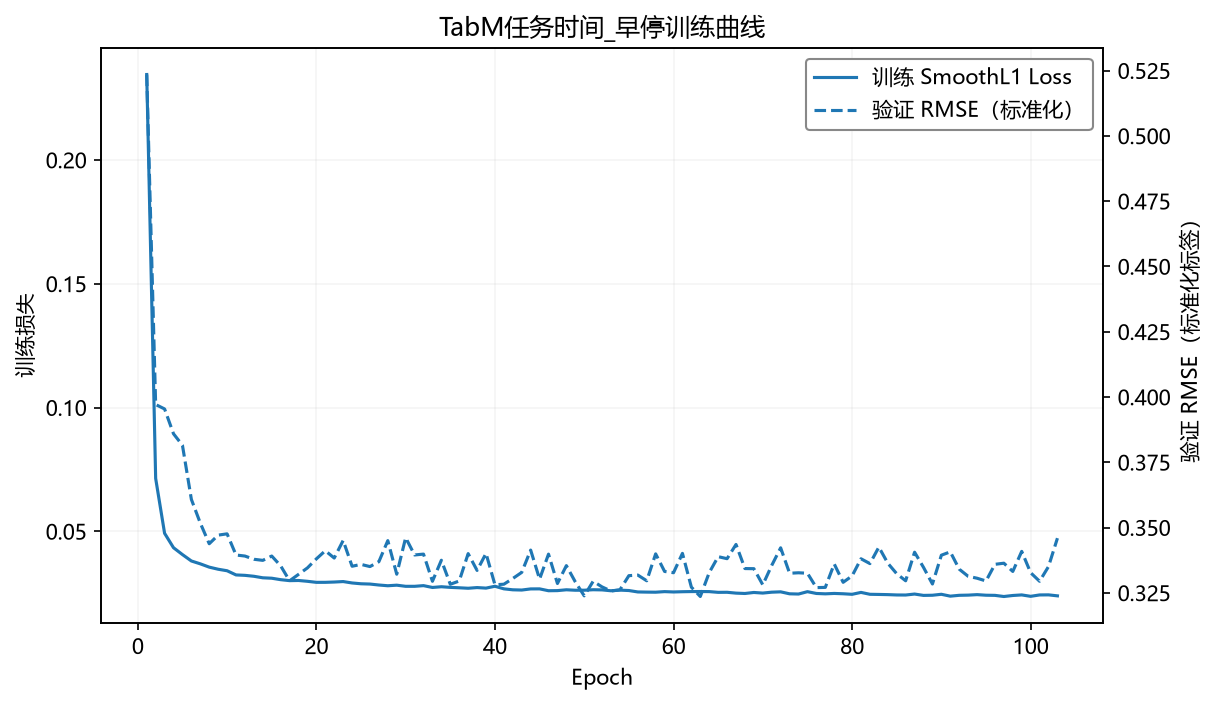

已保存： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\target\TabM_TimeEnergy_V6\plots\TabM任务时间_早停训练曲线.png


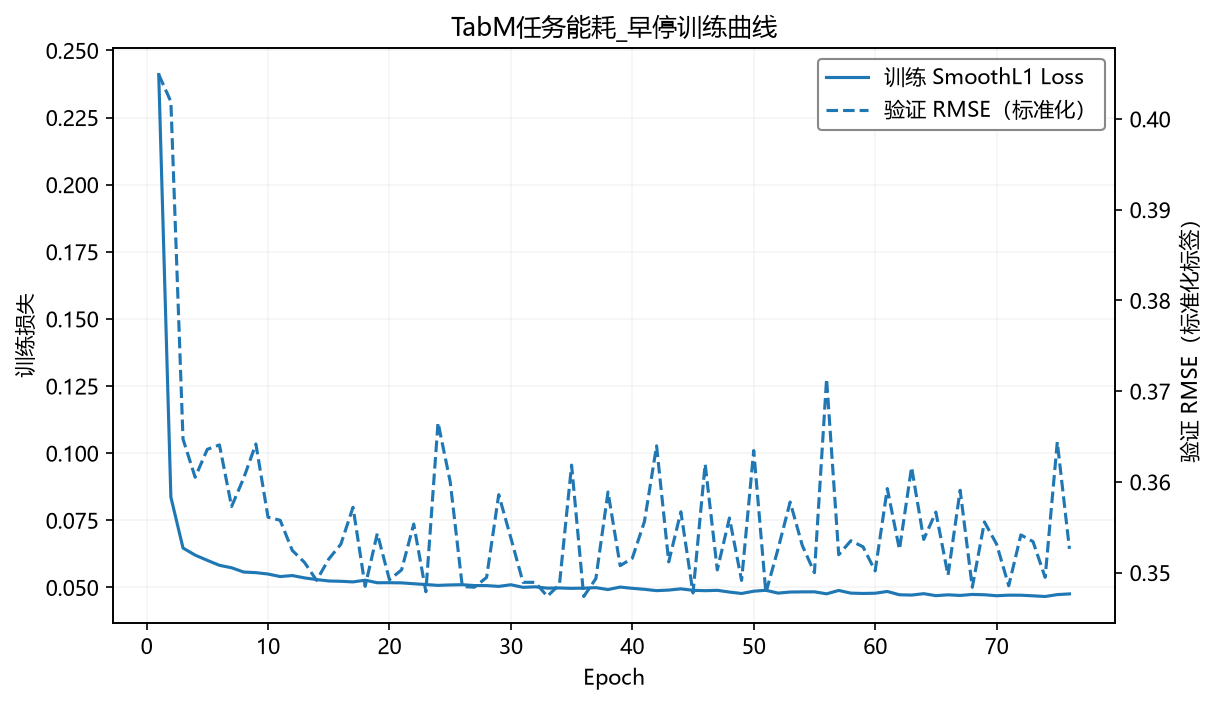

已保存： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\target\TabM_TimeEnergy_V6\plots\TabM任务能耗_早停训练曲线.png


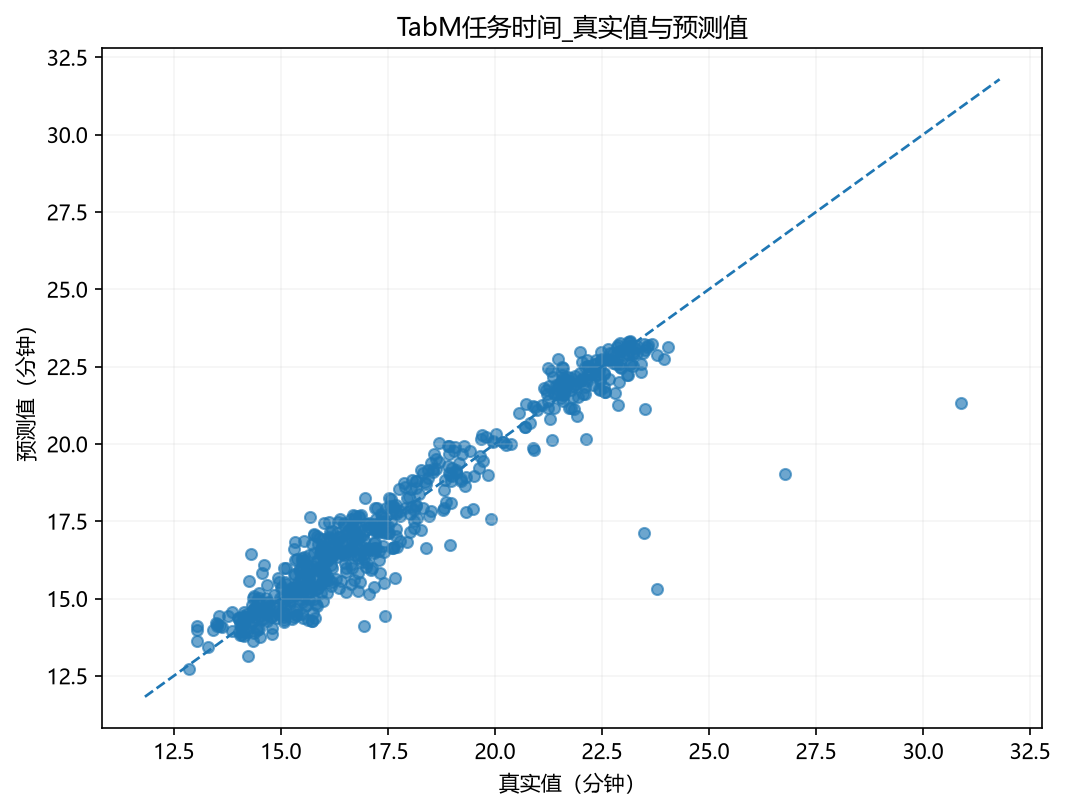

已保存： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\target\TabM_TimeEnergy_V6\plots\TabM任务时间_真实值与预测值.png


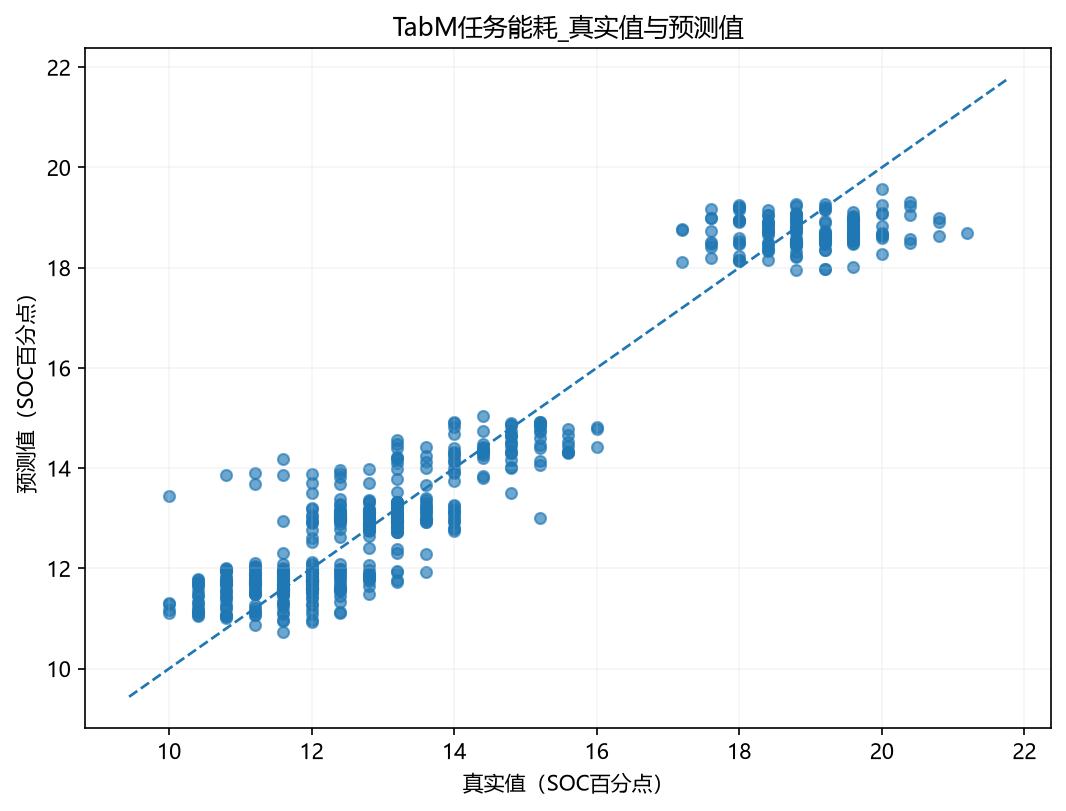

已保存： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\target\TabM_TimeEnergy_V6\plots\TabM任务能耗_真实值与预测值.png


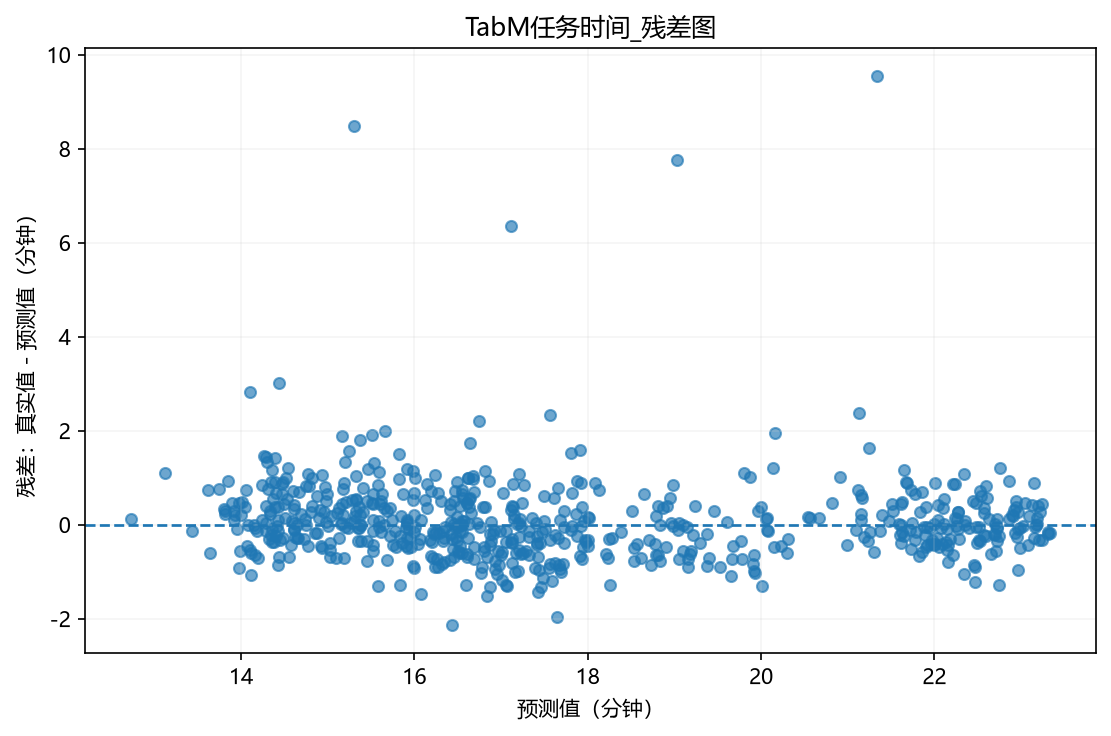

已保存： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\target\TabM_TimeEnergy_V6\plots\TabM任务时间_残差图.png


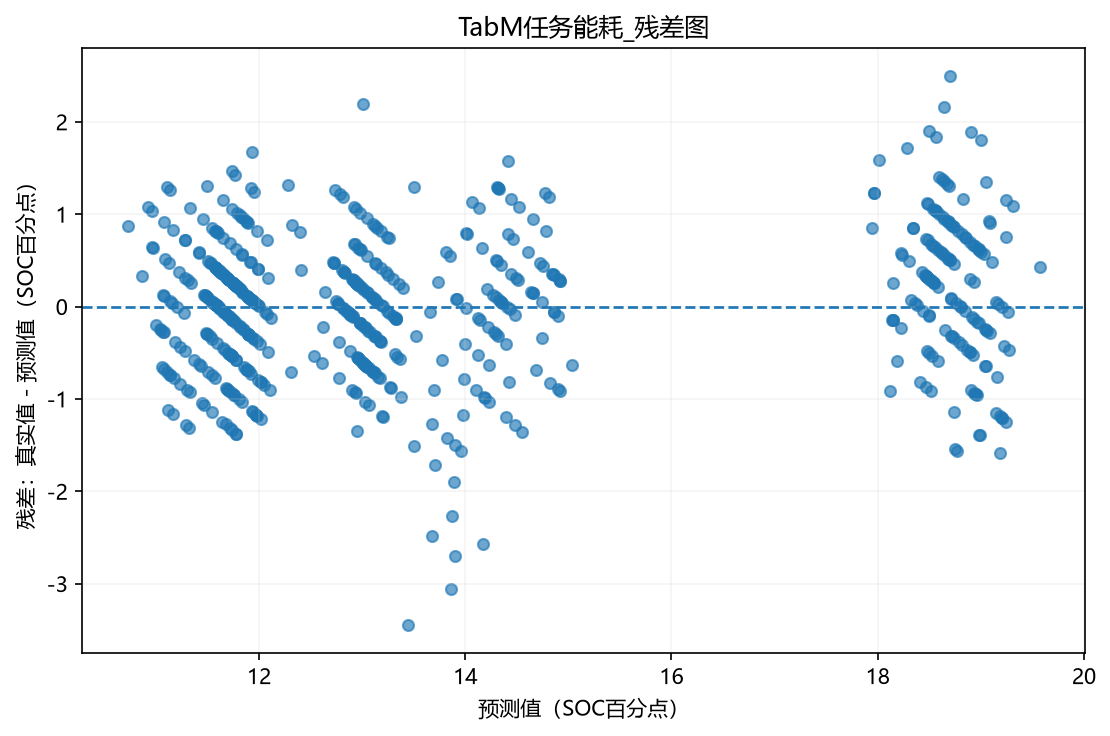

已保存： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\target\TabM_TimeEnergy_V6\plots\TabM任务能耗_残差图.png


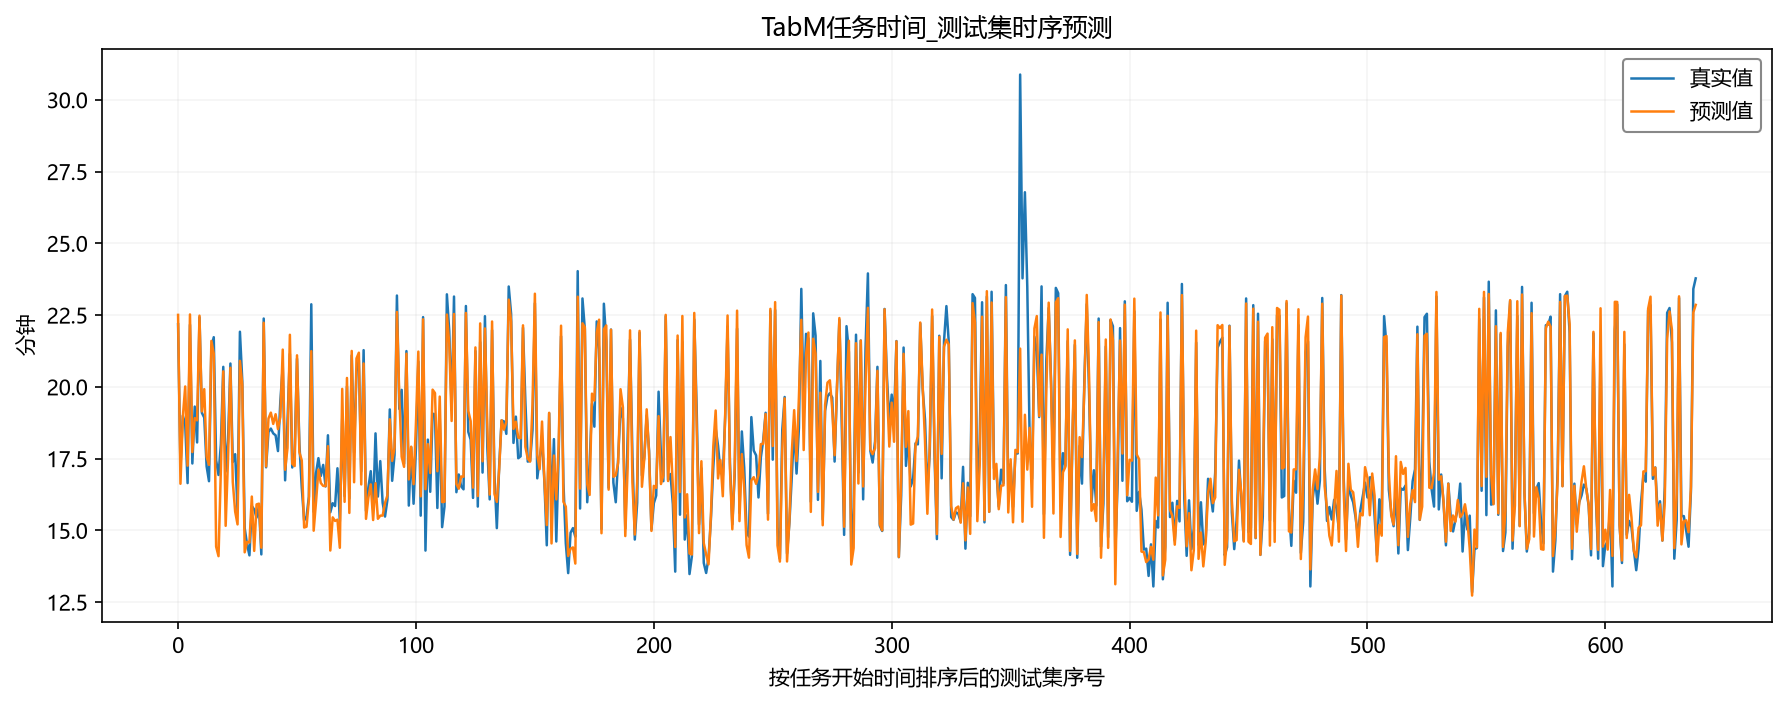

已保存： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\target\TabM_TimeEnergy_V6\plots\TabM任务时间_测试集时序预测.png


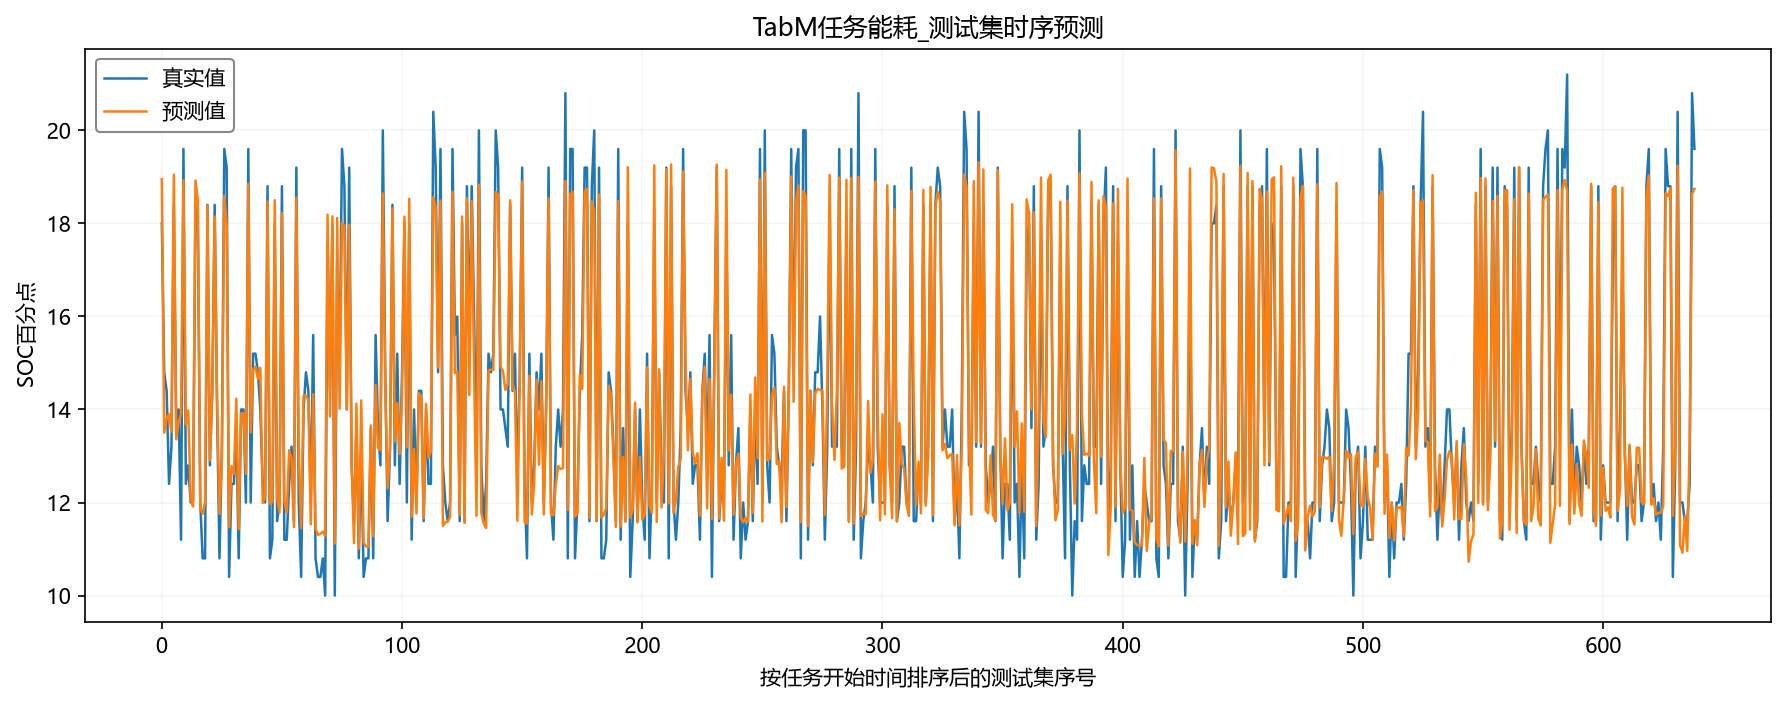

已保存： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\target\TabM_TimeEnergy_V6\plots\TabM任务能耗_测试集时序预测.png


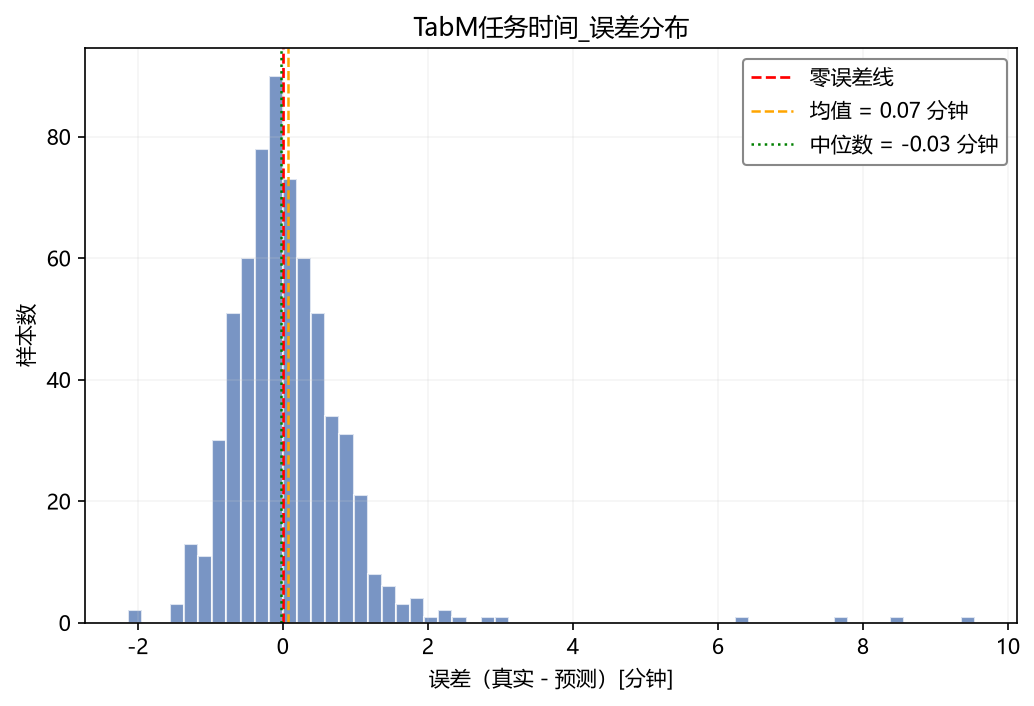

已保存： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\target\TabM_TimeEnergy_V6\plots\TabM任务时间_误差分布.png


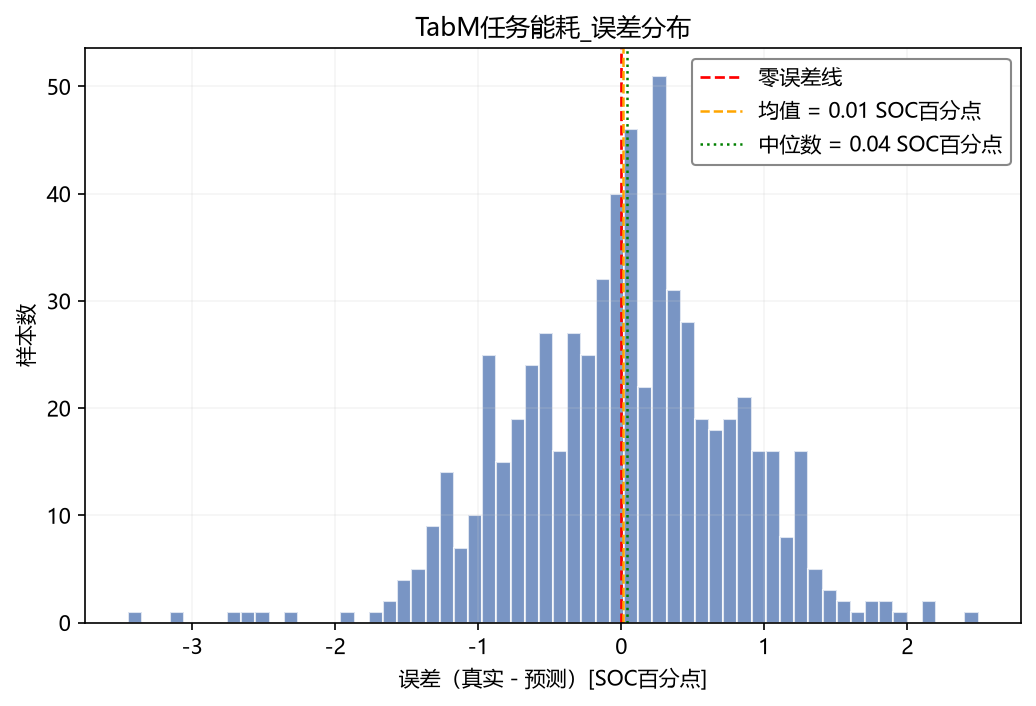

已保存： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\target\TabM_TimeEnergy_V6\plots\TabM任务能耗_误差分布.png


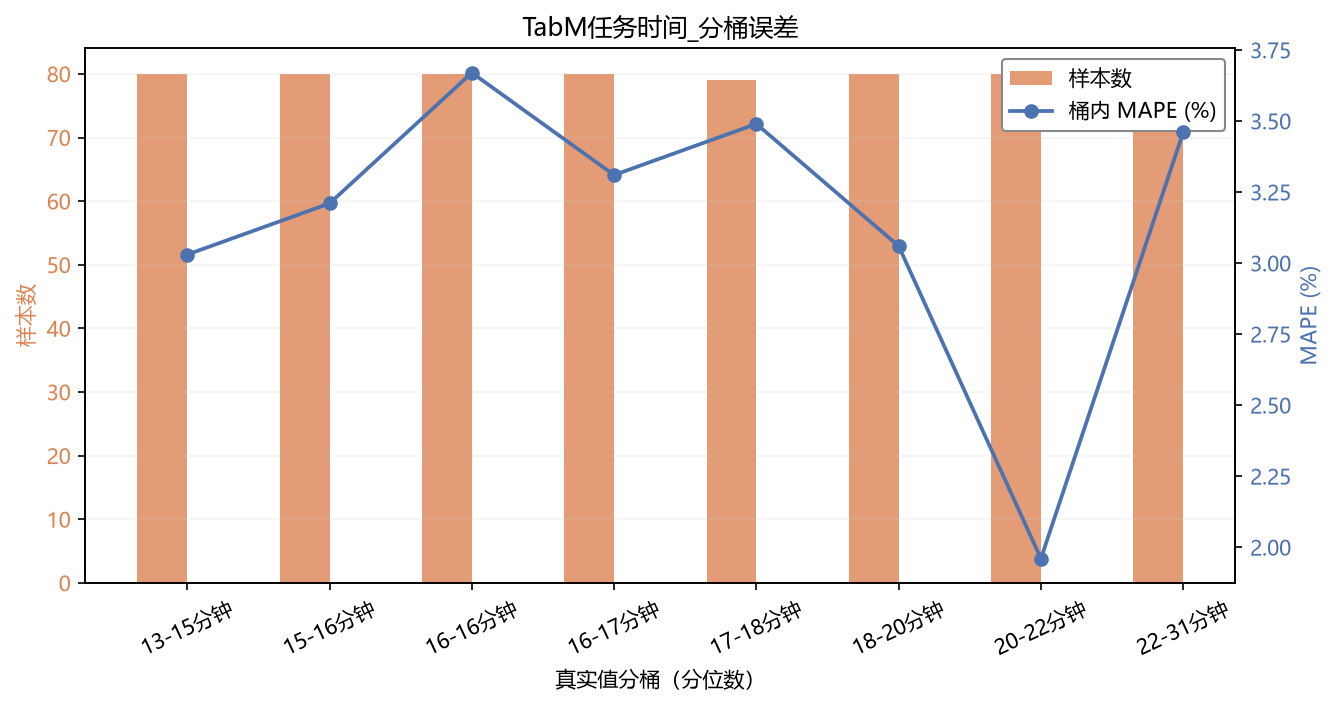

已保存： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\target\TabM_TimeEnergy_V6\plots\TabM任务时间_分桶误差.png


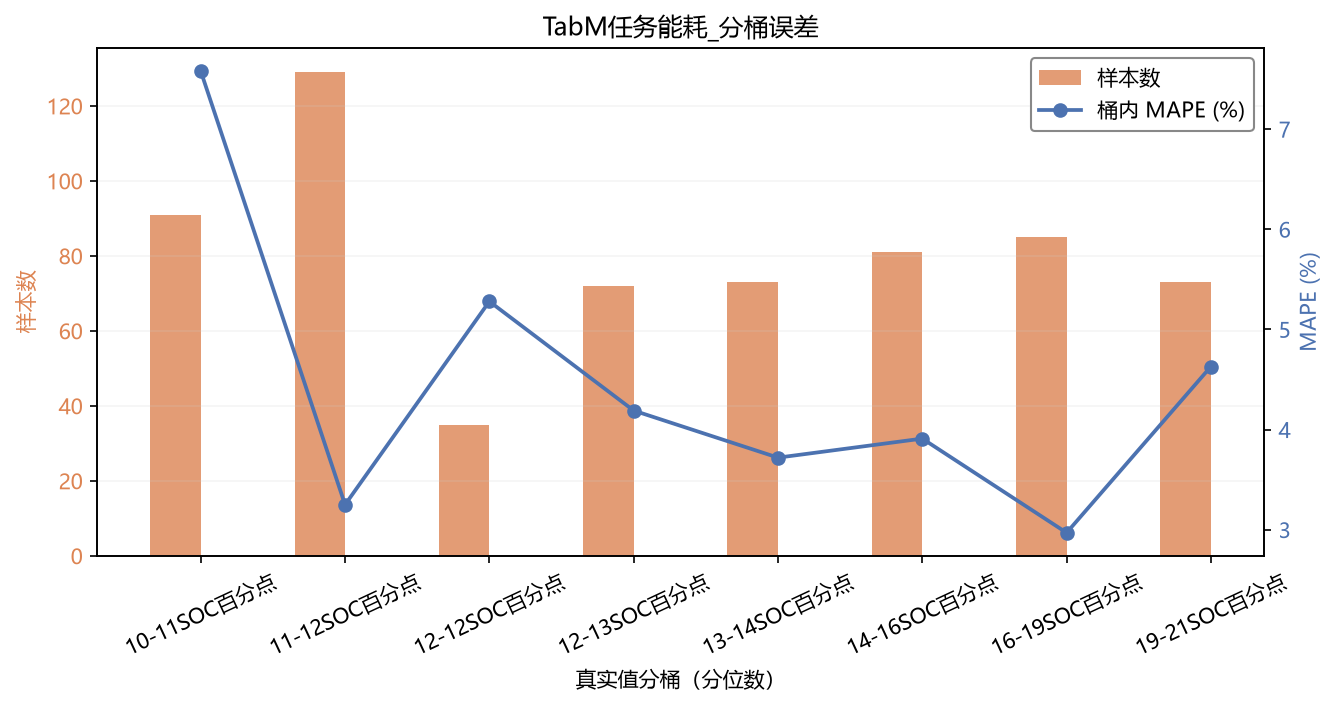

已保存： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\target\TabM_TimeEnergy_V6\plots\TabM任务能耗_分桶误差.png


In [20]:
def safe_filename(title: str) -> str:
    name = re.sub(r"[^0-9A-Za-z一-鿿_-]+", "_", title).strip("_")
    return (name or "plot")[:120] + ".png"


def save_and_display(fig, title: str) -> None:
    path = PLOT_DIR / safe_filename(title)
    fig.savefig(path, dpi=PLOT_DPI, bbox_inches="tight")
    plt.close(fig)
    display(IPythonImage(filename=str(path)))
    print("已保存：", path)


def plot_training_history(history: Dict[str, list], title: str) -> None:
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    fig, ax1 = plt.subplots(figsize=(8.2, 4.8))
    ax1.plot(epochs, history["train_loss"], label="训练 SmoothL1 Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("训练损失")
    ax1.grid(alpha=0.2)

    if history["val_rmse_std"]:
        ax2 = ax1.twinx()
        ax2.plot(epochs, history["val_rmse_std"], linestyle="--", label="验证 RMSE（标准化）")
        ax2.set_ylabel("验证 RMSE（标准化标签）")

        lines = ax1.get_lines() + ax2.get_lines()
        ax1.legend(lines, [line.get_label() for line in lines], loc="best")
    else:
        ax1.legend(loc="best")

    ax1.set_title(title)
    fig.tight_layout()
    save_and_display(fig, title)


def plot_actual_vs_predicted(y_true, y_pred, title: str, unit: str) -> None:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    lower = float(min(y_true.min(), y_pred.min()))
    upper = float(max(y_true.max(), y_pred.max()))
    padding = max((upper - lower) * 0.05, 1e-6)

    fig, ax = plt.subplots(figsize=(7.2, 5.5))
    ax.scatter(y_true, y_pred, s=28, alpha=0.65)
    ax.plot(
        [lower - padding, upper + padding],
        [lower - padding, upper + padding],
        linestyle="--",
        linewidth=1.3,
    )
    ax.set_xlabel(f"真实值（{unit}）")
    ax.set_ylabel(f"预测值（{unit}）")
    ax.set_title(title)
    ax.grid(alpha=0.2)
    fig.tight_layout()
    save_and_display(fig, title)


def plot_residuals(y_true, y_pred, title: str, unit: str) -> None:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    residual = y_true - y_pred

    fig, ax = plt.subplots(figsize=(7.5, 5.0))
    ax.scatter(y_pred, residual, s=28, alpha=0.65)
    ax.axhline(0.0, linestyle="--", linewidth=1.3)
    ax.set_xlabel(f"预测值（{unit}）")
    ax.set_ylabel(f"残差：真实值 - 预测值（{unit}）")
    ax.set_title(title)
    ax.grid(alpha=0.2)
    fig.tight_layout()
    save_and_display(fig, title)


def plot_error_distribution(y_true, y_pred, title: str, unit: str) -> None:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    errors = y_true - y_pred

    fig, ax = plt.subplots(figsize=(7, 4.8))
    ax.hist(errors, bins=60, color="#4C72B0", alpha=0.75, edgecolor="white")
    ax.axvline(0.0, color="red", linestyle="--", linewidth=1.3, label="零误差线")
    ax.axvline(errors.mean(), color="orange", linestyle="--", linewidth=1.2,
               label=f"均值 = {errors.mean():.2f} {unit}")
    ax.axvline(np.median(errors), color="green", linestyle=":", linewidth=1.2,
               label=f"中位数 = {np.median(errors):.2f} {unit}")
    ax.set_xlabel(f"误差（真实 - 预测）[{unit}]")
    ax.set_ylabel("样本数")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.2)
    fig.tight_layout()
    save_and_display(fig, title)


def plot_prediction_sequence(y_true, y_pred, title: str, unit: str) -> None:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    index = np.arange(len(y_true))

    fig, ax = plt.subplots(figsize=(12.0, 4.8))
    ax.plot(index, y_true, linewidth=1.2, label="真实值")
    ax.plot(index, y_pred, linewidth=1.2, label="预测值")
    ax.set_xlabel("按任务开始时间排序后的测试集序号")
    ax.set_ylabel(unit)
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.2)
    fig.tight_layout()
    save_and_display(fig, title)

def plot_error_by_true_value_bins(y_true, y_pred, title: str, unit: str, n_bins: int = 8) -> None:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    abs_err = np.abs(y_true - y_pred)

    df_tmp = pd.DataFrame({"true": y_true, "abs_err": abs_err})
    df_tmp["bin"] = pd.qcut(df_tmp["true"], q=n_bins, duplicates="drop")
    grouped = df_tmp.groupby("bin", observed=False).agg(
        count=("true", "size"),
        mean_true=("true", "mean"),
        mean_abs_err=("abs_err", "mean"),
    )
    grouped["mape"] = (grouped["mean_abs_err"] / grouped["mean_true"] * 100).round(2)

    fig, ax1 = plt.subplots(figsize=(9, 4.8))
    x = np.arange(len(grouped))
    w = 0.35
    ax1.bar(x - w/2, grouped["count"], width=w, color="#DD8452", alpha=0.8, label="样本数")
    ax1.set_xlabel("真实值分桶（分位数）")
    ax1.set_ylabel("样本数", color="#DD8452")
    ax1.tick_params(axis="y", labelcolor="#DD8452")

    ax2 = ax1.twinx()
    ax2.plot(x, grouped["mape"], color="#4C72B0", marker="o", linewidth=1.8, label="桶内 MAPE (%)")
    ax2.set_ylabel("MAPE (%)", color="#4C72B0")
    ax2.tick_params(axis="y", labelcolor="#4C72B0")

    ax1.set_xticks(x)
    ax1.set_xticklabels([f"{b.left:.0f}-{b.right:.0f}{unit}" for b in grouped.index], rotation=25)
    ax1.set_title(title)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
    ax1.grid(alpha=0.2, axis="y")
    fig.tight_layout()
    save_and_display(fig, title)


# 训练曲线
plot_training_history(time_bundle["history"], "TabM任务时间_早停训练曲线")
plot_training_history(energy_bundle["history"], "TabM任务能耗_早停训练曲线")

# 真实值与预测值
plot_actual_vs_predicted(y_time_test, time_pred, "TabM任务时间_真实值与预测值", "分钟")
plot_actual_vs_predicted(y_energy_test, energy_pred, "TabM任务能耗_真实值与预测值", "SOC百分点")

# 残差
plot_residuals(y_time_test, time_pred, "TabM任务时间_残差图", "分钟")
plot_residuals(y_energy_test, energy_pred, "TabM任务能耗_残差图", "SOC百分点")

# 按时间顺序对比
plot_prediction_sequence(y_time_test, time_pred, "TabM任务时间_测试集时序预测", "分钟")
plot_prediction_sequence(y_energy_test, energy_pred, "TabM任务能耗_测试集时序预测", "SOC百分点")

# 误差分布
plot_error_distribution(y_time_test, time_pred, "TabM任务时间_误差分布", "分钟")
plot_error_distribution(y_energy_test, energy_pred, "TabM任务能耗_误差分布", "SOC百分点")

# === 新增图：真实值分桶误差 ===
plot_error_by_true_value_bins(y_time_test, time_pred, "TabM任务时间_分桶误差", "分钟")
plot_error_by_true_value_bins(y_energy_test, energy_pred, "TabM任务能耗_分桶误差", "SOC百分点")

## 9. 保存指标、预测结果和模型

In [21]:
metrics_table.to_csv(
    OUTPUT_DIR / "tabm_test_metrics.csv",
    encoding="utf-8-sig",
)
time_prediction_result.to_csv(
    OUTPUT_DIR / "tabm_time_test_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)
energy_prediction_result.to_csv(
    OUTPUT_DIR / "tabm_energy_test_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

if SAVE_MODELS:
    torch.save(
        {
            "state_dict": time_bundle["model"].state_dict(),
            "feature_columns": TIME_FEATURE_COLS,
            "n_features_after_imputation": int(
                time_bundle["feature_scaler"].n_features_in_
            ),
            "model_config": TABM_CONFIG,
            "best_epoch": int(time_bundle["best_epoch"]),
            "target": TIME_TARGET,
        },
        OUTPUT_DIR / "tabm_time_state.pt",
    )
    joblib.dump(
        {
            "imputer": time_bundle["imputer"],
            "feature_scaler": time_bundle["feature_scaler"],
            "target_scaler": time_bundle["target_scaler"],
        },
        OUTPUT_DIR / "tabm_time_preprocessors.joblib",
    )

    torch.save(
        {
            "state_dict": energy_bundle["model"].state_dict(),
            "feature_columns": ENERGY_FEATURE_COLS,
            "n_features_after_imputation": int(
                energy_bundle["feature_scaler"].n_features_in_
            ),
            "model_config": TABM_CONFIG,
            "best_epoch": int(energy_bundle["best_epoch"]),
            "target": ENERGY_TARGET,
        },
        OUTPUT_DIR / "tabm_energy_state.pt",
    )
    joblib.dump(
        {
            "imputer": energy_bundle["imputer"],
            "feature_scaler": energy_bundle["feature_scaler"],
            "target_scaler": energy_bundle["target_scaler"],
        },
        OUTPUT_DIR / "tabm_energy_preprocessors.joblib",
    )

metadata = {
    "data_file": str(DATA_FILE),
    "output_dir": str(OUTPUT_DIR),
    "base_sample_count": int(len(df)),
    "time_sample_count": int(len(time_df)),
    "energy_sample_count": int(len(energy_df)),
    "time_train_count": int(len(time_train_df)),
    "time_test_count": int(len(time_test_df)),
    "energy_train_count": int(len(energy_train_df)),
    "energy_test_count": int(len(energy_test_df)),
    "time_feature_columns": TIME_FEATURE_COLS,
    "energy_feature_columns": ENERGY_FEATURE_COLS,
    "device": str(DEVICE),
    "tabm_config": TABM_CONFIG,
    "time_best_epoch": int(time_bundle["best_epoch"]),
    "energy_best_epoch": int(energy_bundle["best_epoch"]),
    "time_metrics": time_metrics,
    "energy_metrics": energy_metrics,
}
with (OUTPUT_DIR / "tabm_run_metadata.json").open("w", encoding="utf-8") as file:
    json.dump(metadata, file, ensure_ascii=False, indent=2)

print("全部结果已保存到：", OUTPUT_DIR.resolve())
print("图表目录：", PLOT_DIR.resolve())


全部结果已保存到： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\target\TabM_TimeEnergy_V6
图表目录： C:\Users\Justin.Lv\Desktop\BoLei-DataMining\target\TabM_TimeEnergy_V6\plots


## 输出文件

运行完成后，输出目录包括：

- `tabm_test_metrics.csv`：时间与能耗测试集 MAE、RMSE、R²；
- `tabm_time_test_predictions.csv`：时间模型每个测试任务的真实值、预测值和残差；
- `tabm_energy_test_predictions.csv`：能耗模型每个测试任务的真实值、预测值和残差；
- `plots/`：保持原代码风格的 8 张图（两条训练曲线、两张真实/预测散点图、两张残差图、两张时序预测图）；
- `tabm_time_state.pt`、`tabm_energy_state.pt`：两个模型的参数；
- `tabm_time_preprocessors.joblib`、`tabm_energy_preprocessors.joblib`：两套独立的填补器、特征标准化器和标签标准化器；
- `tabm_run_metadata.json`：运行配置、各自特征列和测试指标。


In [22]:
print("text.color:", plt.rcParams["text.color"])
print("legend.labelcolor:", plt.rcParams["legend.labelcolor"])
print("legend.framealpha:", plt.rcParams["legend.framealpha"])
print("legend.fancybox:", plt.rcParams["legend.fancybox"])
print("patch.facecolor:", plt.rcParams["patch.facecolor"])

# 测试画一个最简单的带中文图例的图，看是不是空白
fig, ax = plt.subplots(figsize=(4,3))
ax.plot([1,2,3], [1,2,3], label="训练 SmoothL1 Loss")
leg = ax.legend()
print("\nlegend 对象文字颜色：", [t.get_color() for t in leg.get_texts()])
print("legend 对象文字内容：", [t.get_text() for t in leg.get_texts()])
plt.close(fig)

text.color: black
legend.labelcolor: black
legend.framealpha: 1.0
legend.fancybox: True
patch.facecolor: C0

legend 对象文字颜色： [array([0., 0., 0., 1.])]
legend 对象文字内容： ['训练 SmoothL1 Loss']
